# emp_model_v7 — Frozen DINOv2-ViT-G/14 Baseline (Phase 1)

**Goal:** Establish a clean DINOv2-only baseline before fine-tuning (v7.1).

**Key differences from v5 (which also used DINOv2):**
- v5 used DINOv2 as 1 of 4 streams in a 10496-d concat with an aggressive bottleneck — signal drowned
- v7 uses DINOv2 **alone** with a proper 3-layer MLP + ArcFace (same architecture as v4.1)
- **8 TTA views** instead of v5's 4 (adds r90/r270 rotations + r504 high-res view)
- **CLS + mean-pooled patch tokens** → 3072-d instead of CLS-only 1536-d
- **Diverse 10-head ensemble** (varied dropout/lr/wd) matching v4.1, not v5's seed-only diversity
- **ArcFace** classifier retained (v5 reverted to cosine — regression)

**Feature dim:** 3072-d (1536 CLS + 1536 patch mean, averaged over 8 views)  
**Embeddings:** `dino_v7_chunks/` → `dino_v7_embeddings.pt`  
**Ensemble:** `/home/david/coin/weights/emp_model_v7_ensemble.pth`

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re, math, copy
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, TensorDataset, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from datetime import datetime
from pathlib import Path
from PIL import Image

In [2]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    ON_COLAB = True
except ImportError:
    ON_COLAB = False
    print('Not running on Colab — skipping drive.mount.')

Not running on Colab — skipping drive.mount.


In [3]:
if ON_COLAB:
    DATA_DIR = r'/content/drive/MyDrive/coin_dataset'
else:
    DATA_DIR = r'/home/david/coin/FOR_TRAINNING'

In [4]:
def folder_label(name):
    return re.sub(r'^\d+_', '', name)

unique_labels = sorted({folder_label(p.name) for p in Path(DATA_DIR).iterdir()
                        if p.is_dir() and (p / 'side_a').exists()})
label_encoder = {name: i for i, name in enumerate(unique_labels)}
num_classes   = len(label_encoder)
print(f'{num_classes} classes from folder structure.')

52 classes from folder structure.


In [5]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cuda:0
GPU: NVIDIA GeForce RTX 3090
VRAM: 25.8 GB


## Feature Extraction — DINOv2-ViT-G/14, 8 views, CLS + patch tokens → 3072-d

**DINOv2 requirements:**
- Input must be multiples of patch size 14: r252 (14×18), r378 (14×27), r504 (14×36)
- ImageNet normalisation (not C-RADIO's conditioner)
- `forward_features()` returns `x_norm_clstoken` (1536-d) + `x_norm_patchtokens` (N_patches × 1536-d)

**8 views:**
1. r252 — base
2. r252 + h-flip
3. r252 + 90° rotation (coins have no canonical orientation)
4. r252 + 270° rotation
5. r378 — mid-res
6. r378 + h-flip
7. r378 + 90° rotation
8. r504 — high-res (sharpens legend text)

**Per view output:** 1536-d CLS + 1536-d patch mean → saved to chunk files.  
**Final:** Average CLS and patch separately across 8 views → concat → 3072-d.

In [6]:
image_dir  = Path(DATA_DIR)
filepaths  = sorted(image_dir.glob('*/side_a/*.jpg'))
raw_labels = [folder_label(p.parent.parent.name) for p in filepaths]
labels_int = [label_encoder[l] for l in raw_labels]
print(f'Total images: {len(filepaths)}')

# All resolutions are multiples of 14 (DINOv2 patch size)
# (name, resolution, h_flip, rotation_degrees)
VIEWS = [
    ('r252',      252, False,   0),   # 14×18
    ('r252_flip', 252, True,    0),
    ('r252_r90',  252, False,  90),   # rotational TTA: coins have no canonical up
    ('r252_r270', 252, False, 270),
    ('r378',      378, False,   0),   # 14×27
    ('r378_flip', 378, True,    0),
    ('r378_r90',  378, False,  90),
    ('r504',      504, False,   0),   # 14×36 — high-res for legend text
]
NUM_CHUNKS    = 10
EXTRACT_BATCH = 8

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

dino_chunk_dir = Path(DATA_DIR) / 'dino_v7_chunks'
dino_final     = Path(DATA_DIR) / 'dino_v7_embeddings.pt'
dino_chunk_dir.mkdir(parents=True, exist_ok=True)


def chunk_ranges(n_total, n_chunks):
    edges = np.linspace(0, n_total, n_chunks + 1, dtype=int)
    return [(i, int(edges[i]), int(edges[i + 1])) for i in range(n_chunks)]

ranges = chunk_ranges(len(filepaths), NUM_CHUNKS)
print(f'{len(VIEWS)} views × {NUM_CHUNKS} chunks = {len(VIEWS) * NUM_CHUNKS} chunk files')

Total images: 62134
8 views × 10 chunks = 80 chunk files


In [7]:
class DinoCoinDataset(Dataset):
    def __init__(self, fps, labs, resolution, flip, rotation):
        self.fps = fps; self.labs = labs
        self.resolution = resolution; self.flip = flip; self.rotation = rotation

    def __len__(self): return len(self.fps)

    def __getitem__(self, i):
        img = Image.open(self.fps[i]).convert('RGB')
        img = img.resize((self.resolution, self.resolution), Image.BILINEAR)
        if self.flip:
            img = img.transpose(Image.FLIP_LEFT_RIGHT)
        if self.rotation:
            img = img.rotate(self.rotation, expand=False)
        arr = torch.from_numpy(np.array(img)).permute(2, 0, 1).float().div_(255.0)
        arr = (arr - IMAGENET_MEAN) / IMAGENET_STD
        return arr, torch.tensor(self.labs[i], dtype=torch.long)


@torch.no_grad()
def run_chunk(model, sub_fp, sub_lb, resolution, flip, rotation):
    ds     = DinoCoinDataset(sub_fp, sub_lb, resolution, flip, rotation)
    loader = DataLoader(ds, batch_size=EXTRACT_BATCH, shuffle=False,
                        num_workers=2, pin_memory=True)
    cls_list, patch_list, labs_list = [], [], []
    for j, (imgs, l) in enumerate(loader):
        imgs = imgs.to(device)
        with torch.autocast('cuda', dtype=torch.bfloat16):
            out     = model.forward_features(imgs)
            cls     = out['x_norm_clstoken']               # (B, 1536)
            patches = out['x_norm_patchtokens'].mean(dim=1) # (B, 1536)
        cls_list.append(cls.float().cpu())
        patch_list.append(patches.float().cpu())
        labs_list.append(l)
        if (j + 1) % 100 == 0:
            print(f'      batch {j + 1}/{len(loader)}')
    return torch.cat(cls_list), torch.cat(patch_list), torch.cat(labs_list)

In [8]:
if dino_final.exists():
    print(f'DINOv2 v7 embeddings already exist — skipping extraction.')
else:
    missing = [
        (vname, res, flip, rot, idx, s, e,
         dino_chunk_dir / f'{vname}_chunk_{idx:02d}.pt')
        for vname, res, flip, rot in VIEWS
        for idx, s, e in ranges
        if not (dino_chunk_dir / f'{vname}_chunk_{idx:02d}.pt').exists()
    ]

    if missing:
        print(f'{len(missing)}/{len(VIEWS) * NUM_CHUNKS} chunks missing — loading DINOv2-ViT-G/14...')
        dino_model = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitg14')
        dino_model = dino_model.to(device).eval()
        for p in dino_model.parameters():
            p.requires_grad = False
        print('DINOv2-ViT-G/14 loaded (1.1B params, 1536-d, patch=14).')

        for vname, res, flip, rot, idx, start, end, out_path in missing:
            print(f'  view={vname}  chunk {idx + 1}/{NUM_CHUNKS}  rows {start}:{end}')
            t0     = datetime.now()
            sub_fp = [str(p) for p in filepaths[start:end]]
            sub_lb = labels_int[start:end]
            cls_f, patch_f, labs = run_chunk(dino_model, sub_fp, sub_lb, res, flip, rot)
            torch.save({'features_cls': cls_f, 'features_patch': patch_f, 'labels': labs},
                       out_path)
            print(f'    saved {out_path.name}  in {datetime.now() - t0}')

        del dino_model
        torch.cuda.empty_cache()
    else:
        print('All chunks on disk — skipping backbone load.')

    # Average CLS and patch separately across all 8 views, then concat
    print('\nAveraging across views and concatenating CLS + patch...')
    sum_cls = None; sum_patch = None; label_tensor = None
    for vname, *_ in VIEWS:
        parts = [torch.load(dino_chunk_dir / f'{vname}_chunk_{i:02d}.pt')
                 for i in range(NUM_CHUNKS)]
        v_cls   = torch.cat([d['features_cls']   for d in parts])
        v_patch = torch.cat([d['features_patch'] for d in parts])
        sum_cls   = v_cls   if sum_cls   is None else sum_cls   + v_cls
        sum_patch = v_patch if sum_patch is None else sum_patch + v_patch
        if label_tensor is None:
            label_tensor = torch.cat([d['labels'] for d in parts])
        print(f'  {vname}: cls={v_cls.shape}  patch={v_patch.shape}')

    avg_cls    = sum_cls   / len(VIEWS)
    avg_patch  = sum_patch / len(VIEWS)
    combined   = torch.cat([avg_cls, avg_patch], dim=-1)  # (N, 3072)
    torch.save({'features': combined, 'labels': label_tensor}, dino_final)
    print(f'\nSaved -> {dino_final}  shape={combined.shape}')

1/80 chunks missing — loading DINOv2-ViT-G/14...


Using cache found in /home/david/.cache/torch/hub/facebookresearch_dinov2_main
/home/david/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/david/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/david/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


DINOv2-ViT-G/14 loaded (1.1B params, 1536-d, patch=14).
  view=r504  chunk 10/10  rows 55920:62134
      batch 100/777
      batch 200/777
      batch 300/777
      batch 400/777
      batch 500/777
      batch 600/777
      batch 700/777
    saved r504_chunk_09.pt  in 0:08:18.208252

Averaging across views and concatenating CLS + patch...
  r252: cls=torch.Size([62134, 1536])  patch=torch.Size([62134, 1536])
  r252_flip: cls=torch.Size([62134, 1536])  patch=torch.Size([62134, 1536])
  r252_r90: cls=torch.Size([62134, 1536])  patch=torch.Size([62134, 1536])
  r252_r270: cls=torch.Size([62134, 1536])  patch=torch.Size([62134, 1536])
  r378: cls=torch.Size([62134, 1536])  patch=torch.Size([62134, 1536])
  r378_flip: cls=torch.Size([62134, 1536])  patch=torch.Size([62134, 1536])
  r378_r90: cls=torch.Size([62134, 1536])  patch=torch.Size([62134, 1536])
  r504: cls=torch.Size([62134, 1536])  patch=torch.Size([62134, 1536])

Saved -> /home/david/coin/FOR_TRAINNING/dino_v7_embeddings.pt  sha

In [9]:
saved     = torch.load(dino_final)
all_feats = saved['features']
all_labs  = saved['labels']
print(f'DINOv2 v7 embeddings: {all_feats.shape}')  # (N, 3072)
print(f'Labels: {all_labs.shape}')

DINOv2 v7 embeddings: torch.Size([62134, 3072])
Labels: torch.Size([62134])


In [10]:
MERGES = {'GORDIAN II': 'GORDIAN I'}

remap  = {label_encoder[src]: label_encoder[tgt] for src, tgt in MERGES.items()}
mapped = all_labs.clone()
for src_idx, tgt_idx in remap.items():
    mapped[all_labs == src_idx] = tgt_idx

kept_names        = [n for n in unique_labels if n not in MERGES]
new_label_encoder = {name: i for i, name in enumerate(kept_names)}
old_to_new        = {label_encoder[name]: new_label_encoder[name] for name in kept_names}

all_labs      = torch.tensor([old_to_new[int(x)] for x in mapped], dtype=torch.long)
label_encoder = new_label_encoder
idx_to_label  = {v: k for k, v in label_encoder.items()}
num_classes   = len(label_encoder)
print(f'After merge: {num_classes} classes.')

train_feats, test_feats, train_labs, test_labs = train_test_split(
    all_feats, all_labs, test_size=0.2, shuffle=True, stratify=all_labs, random_state=42)
train_feats, val_feats, train_labs, val_labs = train_test_split(
    train_feats, train_labs, test_size=0.2, shuffle=True, stratify=train_labs, random_state=42)

feat_dim = train_feats.shape[1]
print(f'Train: {len(train_feats)}  Val: {len(val_feats)}  Test: {len(test_feats)}')
print(f'Feature dim: {feat_dim}')

After merge: 51 classes.
Train: 39765  Val: 9942  Test: 12427
Feature dim: 3072


In [11]:
name_to_prefix = {
    re.sub(r'^\d+_', '', p.name): int(re.match(r'^(\d+)_', p.name).group(1))
    for p in Path(DATA_DIR).iterdir()
    if p.is_dir() and (p / 'side_a').exists()
}

def counts(labs):
    return pd.Series(labs.numpy()).value_counts()

train_c, val_c, test_c = counts(train_labs), counts(val_labs), counts(test_labs)
rows = []
for cls_idx in sorted(set(train_c.index) | set(val_c.index) | set(test_c.index)):
    name = idx_to_label[int(cls_idx)]
    rows.append((name_to_prefix.get(name, 99), name,
                 int(train_c.get(cls_idx, 0)),
                 int(val_c.get(cls_idx, 0)),
                 int(test_c.get(cls_idx, 0))))
rows.sort()
df_counts = pd.DataFrame(rows, columns=['#', 'Emperor', 'Train', 'Val', 'Test'])
df_counts['Total'] = df_counts[['Train', 'Val', 'Test']].sum(axis=1)
print(df_counts.to_string(index=False))
print(f"\nTotals -> Train: {df_counts.Train.sum()}  Val: {df_counts.Val.sum()}  "
      f"Test: {df_counts.Test.sum()}  ({len(df_counts)} classes)")

 #           Emperor  Train  Val  Test  Total
 1          AUGUSTUS   1074  269   336   1679
 2          TIBERIUS    527  132   165    824
 3          CALIGULA    506  126   158    790
 4          CLAUDIUS    882  221   276   1379
 5              NERO    926  232   290   1448
 6             GALBA    991  248   310   1549
 7              OTHO    411  103   129    643
 8         VITELLIUS    568  142   178    888
 9         VESPASIAN   1361  340   425   2126
10             TITUS   1121  280   350   1751
11          DOMITIAN   1309  327   409   2045
12             NERVA   1105  276   345   1726
13            TRAJAN   1066  267   333   1666
14           HADRIAN   1201  301   375   1877
15    ANTONINUS PIUS    613  153   192    958
16   MARCUS AURELIUS   1141  285   356   1782
17      LUCIUS VERUS    786  196   245   1227
18          COMMODUS   1122  281   351   1754
19          PERTINAX    992  248   310   1550
20   DIDIUS JULIANUS    507  127   158    792
21  SEPTIMUS SEVERUS   1501  375  

In [12]:
batch_size    = 512

class_counts  = torch.bincount(train_labs, minlength=num_classes).float()
beta          = 0.9999
effective_num = 1.0 - torch.pow(beta, class_counts)
cb_weights    = (1.0 - beta) / effective_num
cb_weights    = cb_weights / cb_weights.sum() * num_classes
cb_weights    = cb_weights.to(device)

sample_weights = cb_weights.cpu()[train_labs]
train_sampler  = WeightedRandomSampler(sample_weights, num_samples=len(train_labs),
                                        replacement=True)
train_loader = DataLoader(TensorDataset(train_feats, train_labs),
                           batch_size=batch_size, sampler=train_sampler)
val_loader   = DataLoader(TensorDataset(val_feats,   val_labs),
                           batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(TensorDataset(test_feats,  test_labs),
                           batch_size=batch_size, shuffle=False)
print('Loaders ready.')

Loaders ready.


## Model — CoinHeadV7 (3-layer MLP + ArcFace)

Same architecture as v4.1's `CoinHeadV4` — the best-performing head design in the project.
Input dim is 3072-d (DINOv2 CLS + patch mean) instead of v4.1's 3840-d.

`3072 → LayerNorm → 2048 → GELU → Dropout → 2048 → GELU → Dropout → 1024 → GELU → Dropout → ArcFace[51]`

In [13]:
class ArcFaceClassifier(nn.Module):
    def __init__(self, in_dim, n_cls, scale=20.0, margin=0.2):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(n_cls, in_dim))
        nn.init.xavier_uniform_(self.weight)
        self.scale  = scale
        self.margin = margin

    def forward(self, x, labels=None):
        x   = F.normalize(x, dim=-1)
        w   = F.normalize(self.weight, dim=-1)
        cos = x @ w.T
        if labels is None or not self.training:
            return self.scale * cos
        theta      = cos.clamp(-1 + 1e-7, 1 - 1e-7).acos()
        target_cos = (theta + self.margin).cos()
        one_hot    = torch.zeros_like(cos).scatter_(1, labels.unsqueeze(1), 1.0)
        return self.scale * (one_hot * target_cos + (1 - one_hot) * cos)


class CoinHeadV7(nn.Module):
    """3-layer MLP + ArcFace — mirrors v4.1 CoinHeadV4 with 3072-d DINOv2 input."""
    def __init__(self, in_dim, n_cls, hidden=2048, dropout=0.3):
        super().__init__()
        self.body = nn.Sequential(
            nn.LayerNorm(in_dim),
            nn.Linear(in_dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        self.cls = ArcFaceClassifier(hidden // 2, n_cls)

    def forward(self, x, labels=None):
        return self.cls(self.body(x), labels)


print(f'CoinHeadV7: {feat_dim} -> LayerNorm -> 2048 -> 2048 -> 1024 -> ArcFace[{num_classes}]')
print(f'  scale=20, margin=0.2')

CoinHeadV7: 3072 -> LayerNorm -> 2048 -> 2048 -> 1024 -> ArcFace[51]
  scale=20, margin=0.2


## Training Utilities — CE + Mixup + ArcFace + Cluster-aware Hard Mixup

Same setup as v4.1: cluster-aware hard mixup targets the known confusion pairs,
ArcFace margin applies only when the dominant mix label is clear (lam > 0.5).

In [14]:
HARD_CLUSTERS = [
    ['QUINTILLUS', 'AURELIAN', 'CLAUDIUS GOTHICUS'],
    ['VALERIAN', 'AEMILIAN', 'GALLIENUS'],
    ['SEPTIMUS SEVERUS', 'DIDIUS JULIANUS', 'PERTINAX'],
    ['CARACALLA', 'GETA', 'ELAGABALUS', 'SEVERUS ALEXANDER'],
    ['DIOCLETIAN', 'MAXIMIAN', 'CONSTANTIUS I', 'GALERIUS', 'SEVERUS II'],
    ['PHILIP THE ARAB', 'TRAJAN DECIUS', 'TRBONIANUS GALLUS'],
    ['VESPASIAN', 'TITUS'],
    ['NUMERIAN', 'CARINUS', 'CARUS'],
]

cluster_affinity = torch.zeros(num_classes, num_classes, dtype=torch.bool)
for cluster in HARD_CLUSTERS:
    idxs = [label_encoder[n] for n in cluster if n in label_encoder]
    for a in idxs:
        for b in idxs:
            if a != b:
                cluster_affinity[a, b] = True


def cluster_aware_mixup(x, y, alpha=0.3, hard_prob=0.2):
    lam = float(np.random.beta(alpha, alpha))
    B   = x.size(0)
    idx = torch.randperm(B, device=x.device)
    if np.random.random() < hard_prob:
        affinities = cluster_affinity[y.cpu()]
        for i in range(B):
            partners = (affinities[i, y.cpu()] &
                        (torch.arange(B) != i)).nonzero(as_tuple=True)[0]
            if len(partners) > 0:
                idx[i] = partners[torch.randint(len(partners), (1,))]
    return lam * x + (1 - lam) * x[idx], y, y[idx], lam


def arcface_mixup_loss(logits, y_a, y_b, lam, weight, smoothing=0.05):
    log_p = F.log_softmax(logits, dim=-1)
    def one(y):
        nll    = -log_p.gather(1, y.unsqueeze(1)).squeeze(1)
        smooth = -log_p.mean(dim=-1)
        per_ex = (1 - smoothing) * nll + smoothing * smooth
        if weight is not None:
            per_ex = per_ex * weight[y]
        return per_ex.mean()
    return lam * one(y_a) + (1 - lam) * one(y_b)


def make_scheduler(optimizer, total_steps, warmup_steps):
    def lr_lambda(step):
        if step < warmup_steps:
            return step / max(1, warmup_steps)
        prog = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return 0.5 * (1 + math.cos(math.pi * prog))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


print(f'Hard clusters: {len(HARD_CLUSTERS)} groups')

Hard clusters: 8 groups


In [15]:
# Diverse configs — same as v4.1 which outperformed seed-only diversity (v5)
HEAD_CONFIGS = [
    # (seed, hidden, dropout, mixup_alpha, lr,   weight_decay)
    (7000, 2048, 0.30, 0.20, 3e-4, 1e-2),
    (7001, 2048, 0.25, 0.15, 3e-4, 1e-2),
    (7002, 2048, 0.30, 0.20, 2e-4, 5e-3),
    (7003, 2048, 0.25, 0.20, 3e-4, 1e-2),
    (7004, 2048, 0.30, 0.15, 3e-4, 1e-2),
    (7005, 2048, 0.25, 0.20, 4e-4, 1e-2),
    (7006, 2048, 0.30, 0.20, 3e-4, 5e-3),
    (7007, 2048, 0.35, 0.15, 2e-4, 1e-2),
    (7008, 2048, 0.25, 0.20, 3e-4, 1e-2),
    (7009, 2048, 0.30, 0.20, 3e-4, 2e-2),
]
EPOCHS = 100


def train_one_head(seed, hidden=2048, dropout=0.3, mixup_alpha=0.2,
                   lr=3e-4, weight_decay=1e-2, epochs=EPOCHS, verbose=True):
    torch.manual_seed(seed); np.random.seed(seed)
    model     = CoinHeadV7(feat_dim, num_classes, hidden=hidden, dropout=dropout).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    total_steps = epochs * len(train_loader)
    scheduler   = make_scheduler(optimizer, total_steps,
                                  warmup_steps=2 * len(train_loader))
    best_val_acc, best_state = 0.0, None

    for epoch in range(1, epochs + 1):
        t0 = datetime.now()
        model.train()
        running = 0.0
        for feats, targets in train_loader:
            feats, targets = feats.to(device), targets.to(device)
            mixed, y_a, y_b, lam = cluster_aware_mixup(feats, targets,
                                                         alpha=mixup_alpha,
                                                         hard_prob=0.2)
            optimizer.zero_grad()
            margin_labels = y_a if lam > 0.5 else None
            logits = model(mixed, margin_labels)
            loss   = arcface_mixup_loss(logits, y_a, y_b, lam, cb_weights)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            running += loss.item()

        model.eval()
        v_correct, v_total = 0, 0
        with torch.no_grad():
            for feats, targets in val_loader:
                feats, targets = feats.to(device), targets.to(device)
                v_correct += (model(feats).argmax(-1) == targets).sum().item()
                v_total   += targets.size(0)
        val_acc  = v_correct / v_total
        improved = val_acc > best_val_acc
        if improved:
            best_val_acc = val_acc
            best_state   = copy.deepcopy(model.state_dict())

        if verbose and (epoch <= 5 or epoch % 10 == 0 or improved):
            lr_now = optimizer.param_groups[0]['lr']
            print(f'[seed {seed}] ep {epoch:3d}/{epochs}  '
                  f'loss {running / len(train_loader):.4f}  '
                  f'val {val_acc:.4f}  lr {lr_now:.2e}  '
                  f'[{datetime.now() - t0}]' + (' <--' if improved else ''))

    model.load_state_dict(best_state)
    return model, best_val_acc

In [16]:
ensemble = []
for k, (seed, hidden, dropout, alpha, lr, wd) in enumerate(HEAD_CONFIGS):
    print(f'\n=== Head {k + 1}/{len(HEAD_CONFIGS)}  '
          f'hidden={hidden} drop={dropout} α={alpha} lr={lr:.0e} wd={wd:.0e} ===')
    m, vacc = train_one_head(seed, hidden, dropout, alpha, lr, wd,
                              verbose=(k == 0))
    print(f'  -> best val acc: {vacc:.4f}')
    ensemble.append(m.eval())

torch.save([m.state_dict() for m in ensemble], '/home/david/coin/weights/emp_model_v7_ensemble.pth')
print(f'\nSaved {len(ensemble)} heads -> /home/david/coin/weights/emp_model_v7_ensemble.pth')


=== Head 1/10  hidden=2048 drop=0.3 α=0.2 lr=3e-04 wd=1e-02 ===
[seed 7000] ep   1/100  loss 4.8224  val 0.2724  lr 1.50e-04  [0:00:02.714290] <--
[seed 7000] ep   2/100  loss 3.7552  val 0.4614  lr 3.00e-04  [0:00:01.462562] <--
[seed 7000] ep   3/100  loss 3.5498  val 0.5818  lr 3.00e-04  [0:00:01.492022] <--
[seed 7000] ep   4/100  loss 2.9843  val 0.5726  lr 3.00e-04  [0:00:01.099643]
[seed 7000] ep   5/100  loss 2.9531  val 0.5979  lr 2.99e-04  [0:00:01.297239] <--
[seed 7000] ep   7/100  loss 2.5864  val 0.6809  lr 2.98e-04  [0:00:01.303763] <--
[seed 7000] ep  10/100  loss 2.4872  val 0.7088  lr 2.95e-04  [0:00:01.498926] <--
[seed 7000] ep  12/100  loss 2.3880  val 0.7127  lr 2.92e-04  [0:00:01.398341] <--
[seed 7000] ep  13/100  loss 2.4920  val 0.7342  lr 2.91e-04  [0:00:01.146434] <--
[seed 7000] ep  16/100  loss 2.2791  val 0.7391  lr 2.85e-04  [0:00:01.395119] <--
[seed 7000] ep  19/100  loss 2.2559  val 0.7470  lr 2.78e-04  [0:00:01.205435] <--
[seed 7000] ep  20/100  lo

## Inference — Ensemble + Prototype kNN + Raw kNN

Same three-way fusion as v4.1 with val-set sweep to find best weights.

In [17]:
@torch.no_grad()
def ensemble_probs(feats):
    feats = feats.to(device)
    probs = None
    for m in ensemble:
        p     = F.softmax(m(feats), dim=-1)
        probs = p if probs is None else probs + p
    return probs / len(ensemble)


train_norm_all = F.normalize(train_feats.to(device), dim=-1)
train_labs_dev = train_labs.to(device)

prototypes = torch.zeros(num_classes, feat_dim, device=device)
for c in range(num_classes):
    mask = train_labs_dev == c
    if mask.sum() > 0:
        prototypes[c] = F.normalize(train_norm_all[mask].mean(0), dim=-1)
print(f'Prototypes: {prototypes.shape}')


@torch.no_grad()
def proto_knn_probs(feats, temperature=20.0):
    q    = F.normalize(feats.to(device), dim=-1)
    sims = q @ prototypes.T
    return F.softmax(sims * temperature, dim=-1)


@torch.no_grad()
def raw_knn_probs(feats, K=25, temperature=20.0):
    q    = F.normalize(feats.to(device), dim=-1)
    sims = q @ train_norm_all.T
    vals, idx = sims.topk(K, dim=-1)
    wts  = F.softmax(vals * temperature, dim=-1)
    nlabs = train_labs_dev[idx]
    out  = torch.zeros(q.size(0), num_classes, device=device)
    out.scatter_add_(1, nlabs, wts)
    return out


@torch.no_grad()
def fused_predict(feats, ap=0.2, ak=0.1):
    e = ensemble_probs(feats)
    p = proto_knn_probs(feats)
    k = raw_knn_probs(feats)
    return (1 - ap - ak) * e + ap * p + ak * k

Prototypes: torch.Size([51, 3072])


In [18]:
print('Sweeping fusion weights on val set...')
results = {}
for ap in [0.0, 0.1, 0.2, 0.3]:
    for ak in [0.0, 0.1, 0.2]:
        if ap + ak > 0.6:
            continue
        correct, total = 0, 0
        for feats, targets in val_loader:
            targets = targets.to(device)
            probs   = fused_predict(feats, ap, ak)
            correct += (probs.argmax(-1) == targets).sum().item()
            total   += targets.size(0)
        results[(ap, ak)] = correct / total
        print(f'  ap={ap:.1f}  ak={ak:.1f}  -> val={correct / total:.4f}')

best_ap, best_ak = max(results, key=results.get)
print(f'\nBest: ap={best_ap}  ak={best_ak}  val={results[(best_ap, best_ak)]:.4f}')

Sweeping fusion weights on val set...
  ap=0.0  ak=0.0  -> val=0.8508
  ap=0.0  ak=0.1  -> val=0.8510
  ap=0.0  ak=0.2  -> val=0.8511
  ap=0.1  ak=0.0  -> val=0.8508
  ap=0.1  ak=0.1  -> val=0.8510
  ap=0.1  ak=0.2  -> val=0.8510
  ap=0.2  ak=0.0  -> val=0.8508
  ap=0.2  ak=0.1  -> val=0.8511
  ap=0.2  ak=0.2  -> val=0.8509
  ap=0.3  ak=0.0  -> val=0.8509
  ap=0.3  ak=0.1  -> val=0.8509
  ap=0.3  ak=0.2  -> val=0.8507

Best: ap=0.0  ak=0.2  val=0.8511


In [19]:
def evaluate(loader, name, ap=best_ap, ak=best_ak):
    correct, total = 0, 0
    for feats, targets in loader:
        targets = targets.to(device)
        probs   = fused_predict(feats, ap, ak)
        correct += (probs.argmax(-1) == targets).sum().item()
        total   += targets.size(0)
    acc = correct / total
    print(f'{name}: {acc:.4f}  ({correct}/{total})')
    return acc


print('--- Ensemble only ---')
evaluate(val_loader,  'Val  ', 0.0, 0.0)
evaluate(test_loader, 'Test ', 0.0, 0.0)

print(f'\n--- Ensemble + proto-kNN + raw-kNN  (ap={best_ap}, ak={best_ak}) ---')
evaluate(val_loader,  'Val  ')
test_acc = evaluate(test_loader, 'Test ')
print(f'\nFinal test accuracy: {test_acc:.6f}')

--- Ensemble only ---
Val  : 0.8508  (8459/9942)
Test : 0.8575  (10656/12427)

--- Ensemble + proto-kNN + raw-kNN  (ap=0.0, ak=0.2) ---
Val  : 0.8511  (8462/9942)
Test : 0.8578  (10660/12427)

Final test accuracy: 0.857810


In [20]:
class_order   = sorted(range(num_classes), key=lambda i: name_to_prefix[idx_to_label[i]])
display_names = [f"{name_to_prefix[idx_to_label[i]]:02d}_{idx_to_label[i]}" for i in class_order]

cm = np.zeros((num_classes, num_classes), dtype=int)
with torch.no_grad():
    for feats, targets in test_loader:
        targets = targets.to(device)
        preds   = fused_predict(feats, best_ap, best_ak).argmax(-1)
        for t, p in zip(targets.cpu(), preds.cpu()):
            cm[t.item(), p.item()] += 1
cm = cm[np.ix_(class_order, class_order)]

total_correct = int(cm.diagonal().sum())
total         = int(cm.sum())
print(f'Overall test accuracy: {total_correct}/{total} = {total_correct / total:.4f}')
print(f'Classes: {num_classes}\n')

row_acc = cm.diagonal() / cm.sum(axis=1).clip(min=1)
TOP_CONFUSIONS = 3
print('Per-class breakdown (worst first):')
for i in np.argsort(row_acc):
    n_total   = int(cm[i].sum())
    n_correct = int(cm[i, i])
    acc_cls   = n_correct / max(n_total, 1)
    print(f'\n{display_names[i]}: {n_correct}/{n_total}  acc={acc_cls:.3f}')
    off = sorted(
        ((j, int(cm[i, j])) for j in range(num_classes) if j != i and cm[i, j] > 0),
        key=lambda x: -x[1],
    )
    if not off:
        print('  (no mistakes)')
        continue
    for j, count in off[:TOP_CONFUSIONS]:
        print(f'  -> {display_names[j]}: {count} ({count / max(n_total, 1):.1%})')
    remaining = sum(c for _, c in off[TOP_CONFUSIONS:])
    if remaining:
        print(f'  -> other: {remaining}')

Overall test accuracy: 10660/12427 = 0.8578
Classes: 51

Per-class breakdown (worst first):

41_QUINTILLUS: 66/140  acc=0.471
  -> 42_AURELIAN: 40 (28.6%)
  -> 40_CLAUDIUS GOTHICUS: 29 (20.7%)
  -> 38_VALERIAN: 2 (1.4%)
  -> other: 3

38_VALERIAN: 61/122  acc=0.500
  -> 37_AEMILIAN: 28 (23.0%)
  -> 39_GALLIENUS: 24 (19.7%)
  -> 18_COMMODUS: 2 (1.6%)
  -> other: 7

49_DIOCLETIAN: 136/212  acc=0.642
  -> 50_MAXIMIAN: 23 (10.8%)
  -> 52_GALERIUS: 16 (7.5%)
  -> 47_NUMERIAN: 8 (3.8%)
  -> other: 29

21_SEPTIMUS SEVERUS: 302/469  acc=0.644
  -> 20_DIDIUS JULIANUS: 125 (26.7%)
  -> 18_COMMODUS: 15 (3.2%)
  -> 19_PERTINAX: 7 (1.5%)
  -> other: 20

37_AEMILIAN: 105/152  acc=0.691
  -> 38_VALERIAN: 35 (23.0%)
  -> 39_GALLIENUS: 4 (2.6%)
  -> 36_TRBONIANUS GALLUS: 3 (2.0%)
  -> other: 5

52_GALERIUS: 121/169  acc=0.716
  -> 50_MAXIMIAN: 18 (10.7%)
  -> 49_DIOCLETIAN: 12 (7.1%)
  -> 53_SEVERUS II: 7 (4.1%)
  -> other: 11

50_MAXIMIAN: 146/203  acc=0.719
  -> 49_DIOCLETIAN: 18 (8.9%)
  -> 52_GALER

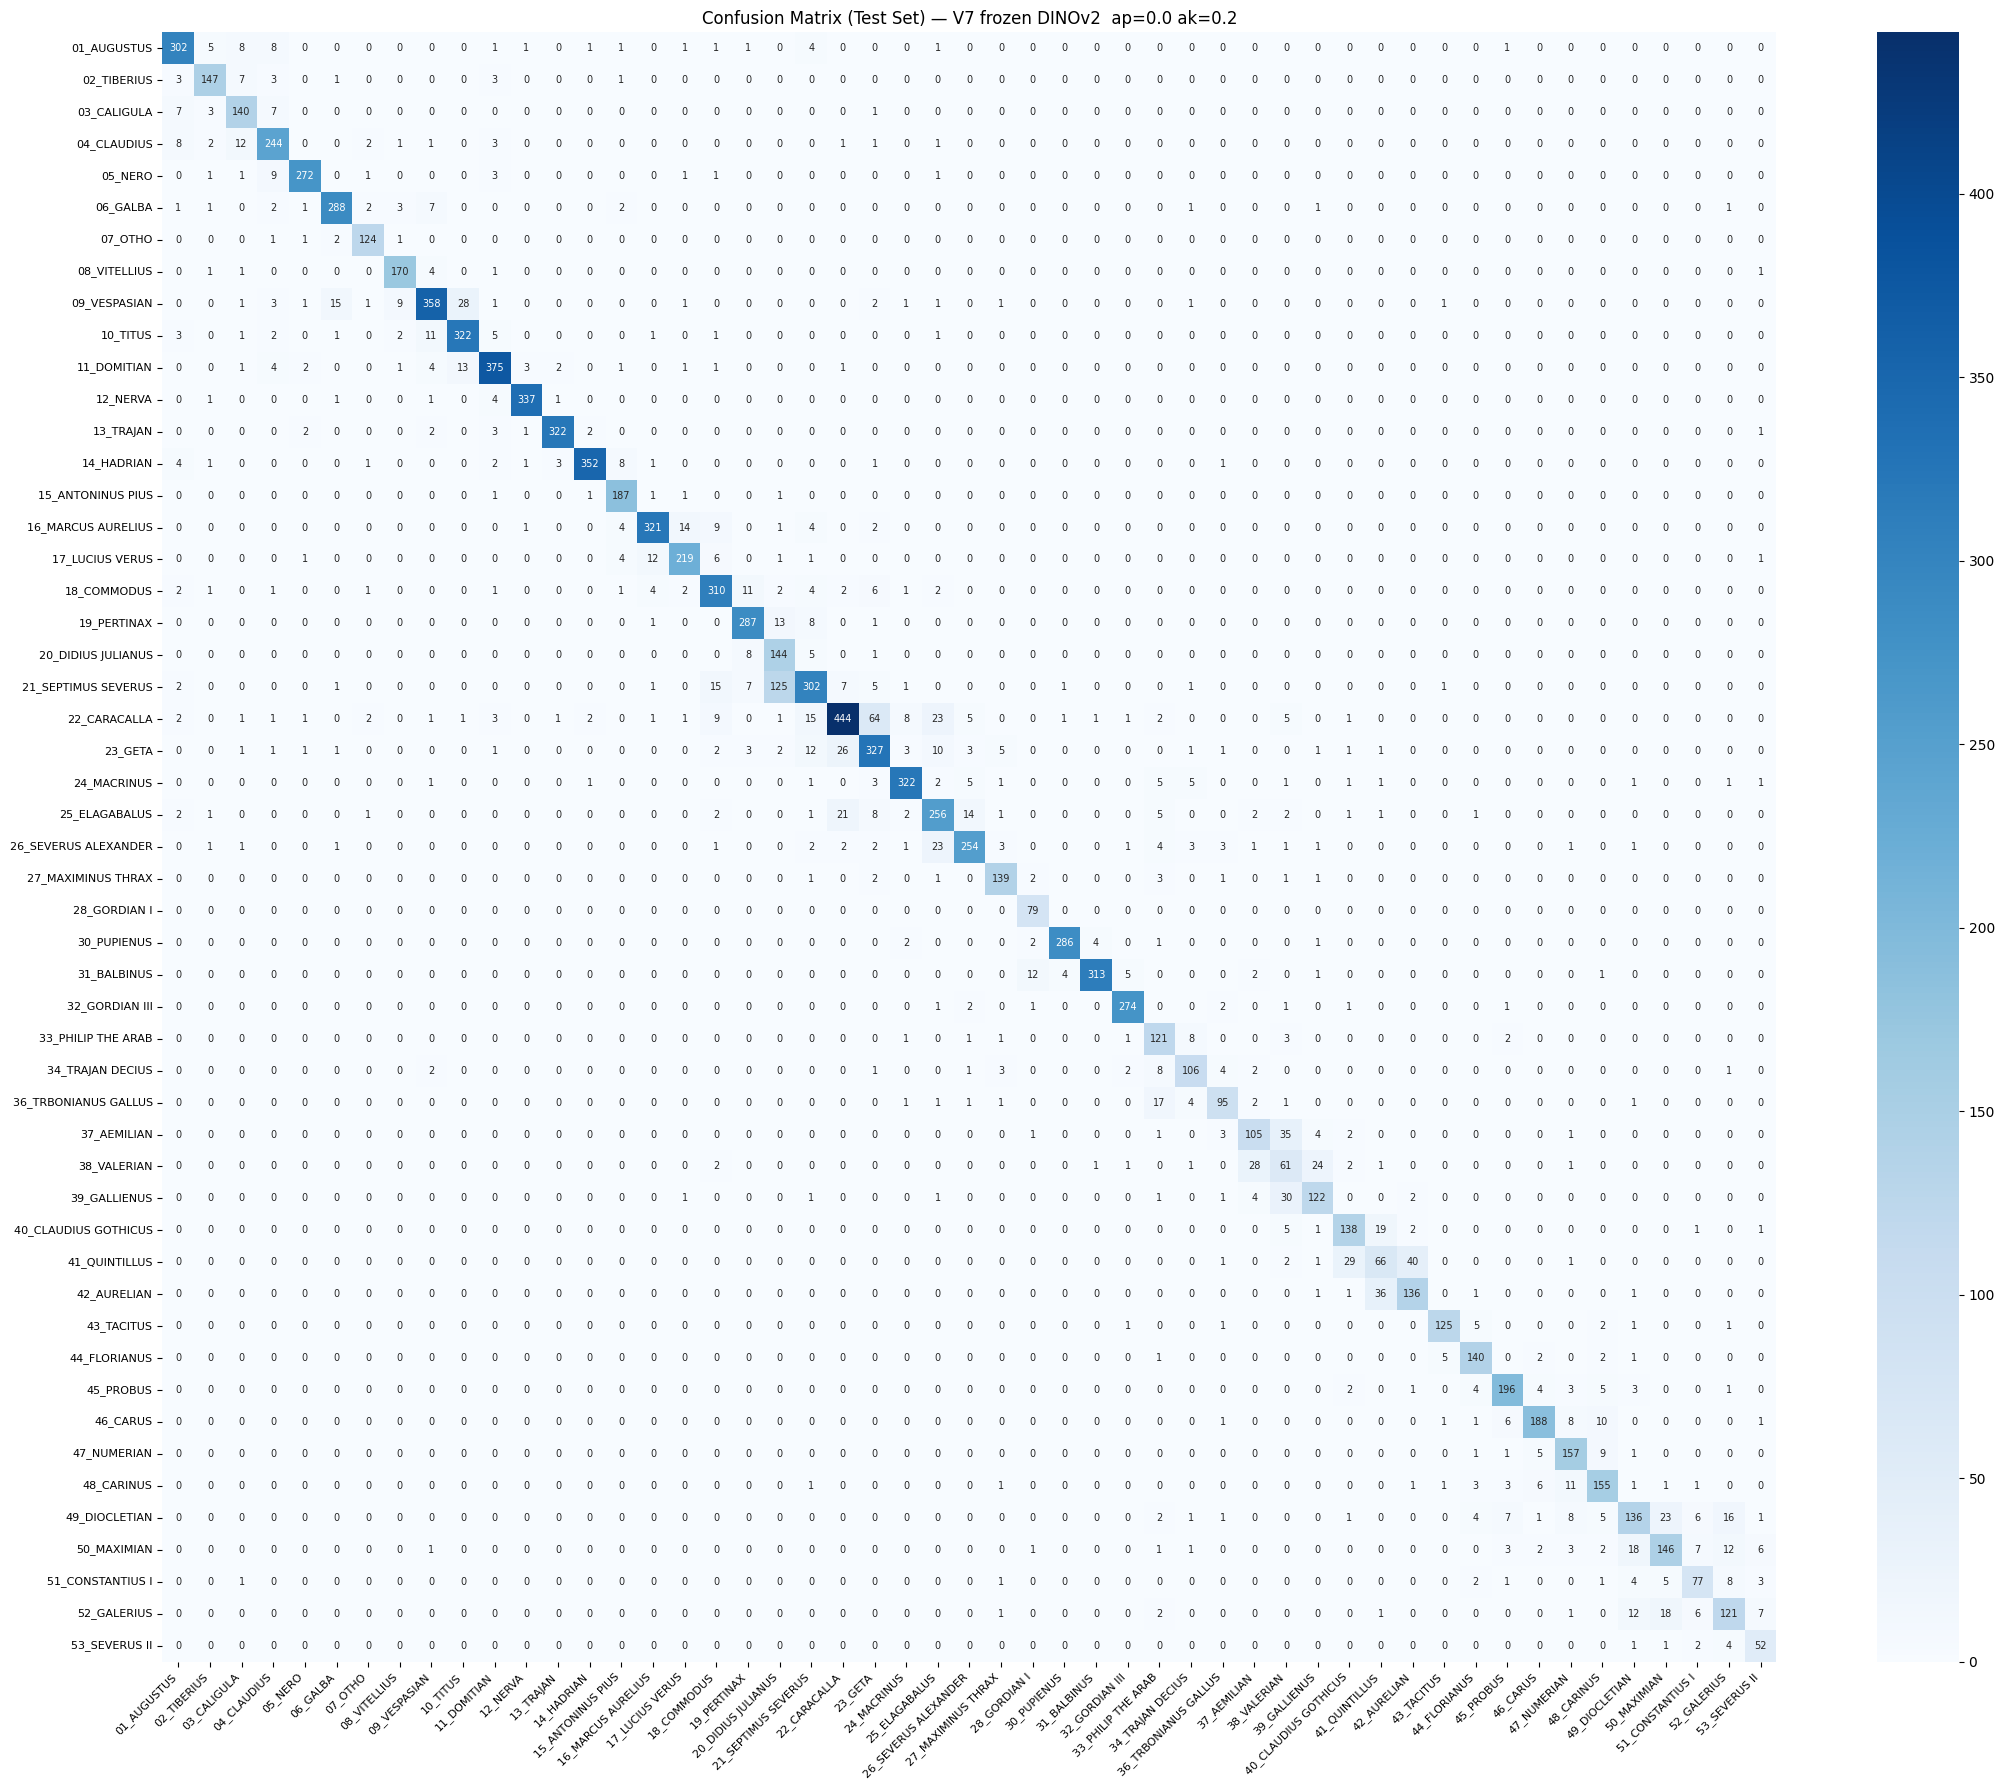

In [21]:
df_cm = pd.DataFrame(cm, index=display_names, columns=display_names)
plt.figure(figsize=(22, 18))
sns.heatmap(df_cm, annot=True, fmt='d', cmap='Blues', annot_kws={'size': 7})
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.title(f'Confusion Matrix (Test Set) — V7 frozen DINOv2  ap={best_ap} ak={best_ak}')
plt.tight_layout()
plt.show()

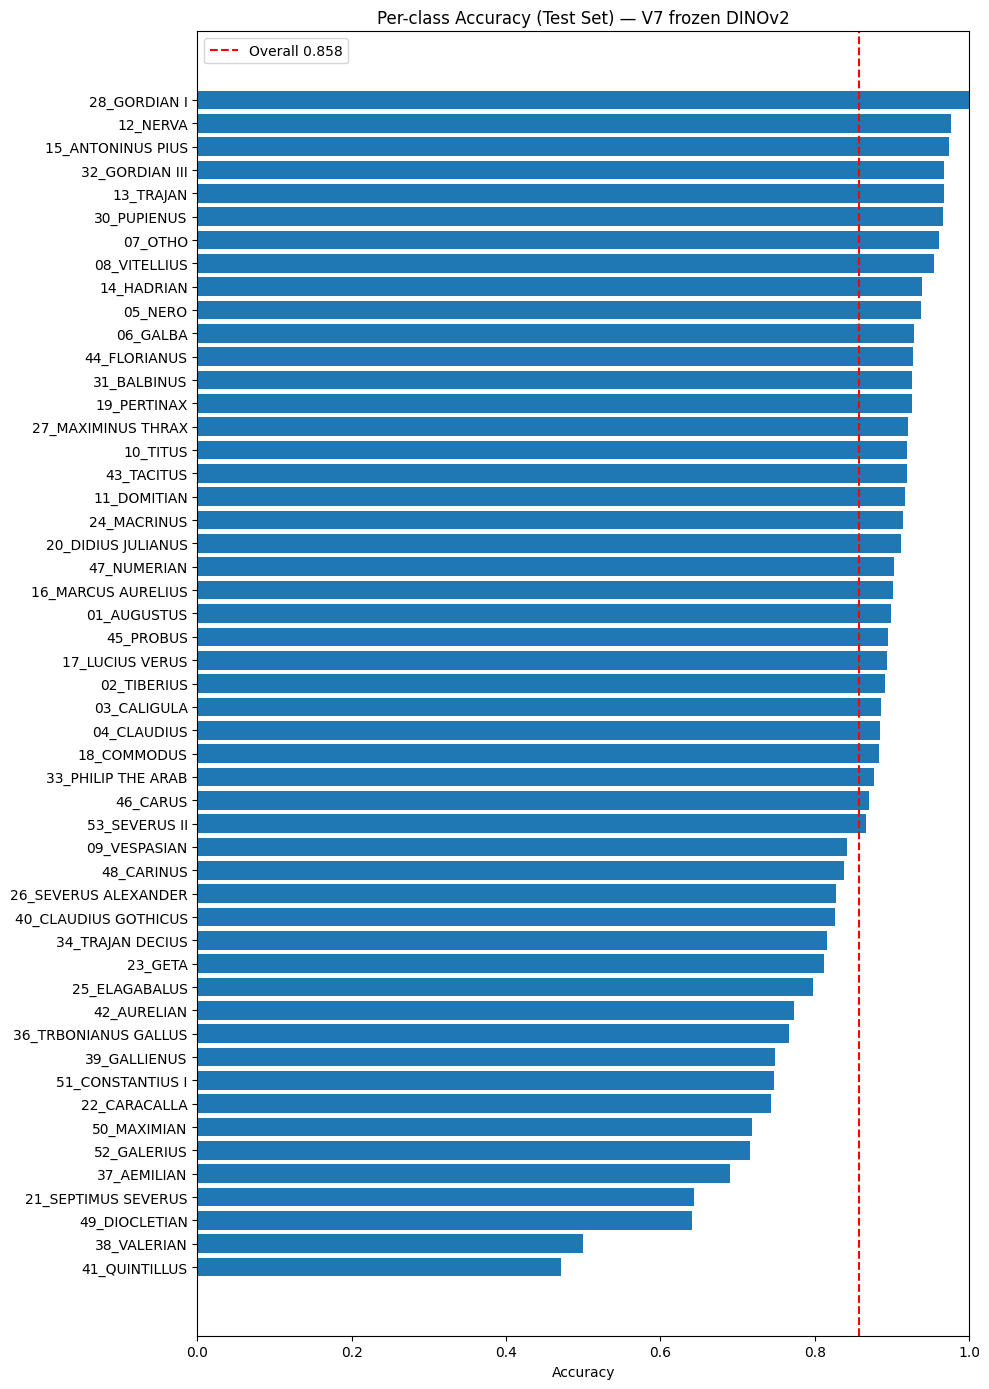

             Emperor  Accuracy
       41_QUINTILLUS  0.471429
         38_VALERIAN  0.500000
       49_DIOCLETIAN  0.641509
 21_SEPTIMUS SEVERUS  0.643923
         37_AEMILIAN  0.690789
         52_GALERIUS  0.715976
         50_MAXIMIAN  0.719212
        22_CARACALLA  0.743719
    51_CONSTANTIUS I  0.747573
        39_GALLIENUS  0.748466
36_TRBONIANUS GALLUS  0.766129
         42_AURELIAN  0.772727
       25_ELAGABALUS  0.797508
             23_GETA  0.811414
    34_TRAJAN DECIUS  0.815385
40_CLAUDIUS GOTHICUS  0.826347
26_SEVERUS ALEXANDER  0.827362
          48_CARINUS  0.837838
        09_VESPASIAN  0.842353
       53_SEVERUS II  0.866667
            46_CARUS  0.870370
  33_PHILIP THE ARAB  0.876812
         18_COMMODUS  0.883191
         04_CLAUDIUS  0.884058
         03_CALIGULA  0.886076
         02_TIBERIUS  0.890909
     17_LUCIUS VERUS  0.893878
           45_PROBUS  0.894977
         01_AUGUSTUS  0.898810
  16_MARCUS AURELIUS  0.901685
         47_NUMERIAN  0.902299
  20_DID

In [22]:
per_class_acc = cm.diagonal() / cm.sum(axis=1).clip(min=1)
acc_df = pd.DataFrame({'Emperor': display_names, 'Accuracy': per_class_acc}).sort_values('Accuracy')

plt.figure(figsize=(10, 14))
plt.barh(acc_df['Emperor'], acc_df['Accuracy'])
plt.axvline(x=total_correct / total, color='red', linestyle='--', label=f'Overall {total_correct/total:.3f}')
plt.xlabel('Accuracy')
plt.title('Per-class Accuracy (Test Set) — V7 frozen DINOv2')
plt.xlim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

print(acc_df.to_string(index=False))